In [1]:
import os
print("현재 폴더:", os.getcwd())
print()
print("이 폴더 안의 파일/폴더:")
for item in os.listdir('.'):
    print(" -", item)

현재 폴더: c:\Users\poror\OneDrive\바탕 화면\Projects\추천시스템

이 폴더 안의 파일/폴더:
 - .git
 - .gitignore
 - 01_Exploratory-Analysis-on-100K-data.ipynb
 - k_sweep.png
 - mf_generate_outputs.py
 - ml-100k
 - ml-100k (1).zip
 - movie_data.ipynb
 - outputs
 - README.md


import os파일/폴더 조작 라이브러리 불러오기
os.getcwd()현재 작업 폴더 경로 출력
os.listdir('.')현재 폴더 안 파일 목록 출력

In [2]:
import pandas as pd

train = pd.read_csv(
    'ml-100k/ua.base',
    sep='\t',
    names=['user', 'item', 'rating', 'timestamp']
)

print("총 평점 개수:", len(train))
print(train.head())

총 평점 개수: 90570
   user  item  rating  timestamp
0     1     1       5  874965758
1     1     2       3  876893171
2     1     3       4  878542960
3     1     4       3  876893119
4     1     5       3  889751712


import pandas as pd 데이터 처리 라이브러리 불러오기
pd.read_csv(...)CSV 파일 읽기
sep='\t'구분자가 탭(\t)이라는 뜻 (쉼표 아님)
names=[...]열 이름이 없으니 직접 지정: 사용자·아이템·평점·시간

In [3]:
import os
print(os.listdir('ml-100k'))

['allbut.pl', 'mku.sh', 'README', 'u.data', 'u.genre', 'u.info', 'u.item', 'u.occupation', 'u.user', 'u1.base', 'u1.test', 'u2.base', 'u2.test', 'u3.base', 'u3.test', 'u4.base', 'u4.test', 'u5.base', 'u5.test', 'ua.base', 'ua.test', 'ub.base', 'ub.test']


In [4]:
%pip install pandas numpy matplotlib
%pip install --upgrade pip
import pandas as pd

train = pd.read_csv(
    'ml-100k/ua.base',
    sep='\t',
    names=['user', 'item', 'rating', 'timestamp']
)

print("총 평점 개수:", len(train))
print("첫 5줄:")
print(train.head())

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 6.5 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.1.1
    Uninstalling pip-26.1.1:
      Successfully uninstalled pip-26.1.1
Note: you may need to restart the kernel to use updated packages.
총 평점 개수: 90570
첫 5줄:
   user  item  rating  timestamp
0     1     1       5  874965758
1     1     2       3  876893171
2     1     3       4  878542960
3     1     4       3  876893119
4     1     5       3  889751712


user  item  rating  timestamp
0     1     1       5  874965758

user 1번 사용자가
item 1번 영화에
5점 평점을 매겼고
그 시각이 timestamp 874965758 (1997년 9월 20일이라는 뜻, 유닉스 시간이라서 사람이 읽기 힘듦)

In [5]:
print("사용자 수:", train['user'].nunique())
print("영화 수:", train['item'].nunique())
print()
print("평점 분포:")
print(train['rating'].value_counts().sort_index())

사용자 수: 943
영화 수: 1680

평점 분포:
rating
1     5568
2    10375
3    24721
4    30858
5    19048
Name: count, dtype: int64


In [6]:
import numpy as np

# 매번 같은 결과 나오게 시드 고정
np.random.seed(42)

# 인덱스를 무작위로 섞어서 85% / 15%로 자르기
n = len(train)
indices = np.random.permutation(n)
split = int(n * 0.85)

train_set = train.iloc[indices[:split]].reset_index(drop=True)
val_set   = train.iloc[indices[split:]].reset_index(drop=True)

print("학습:", len(train_set))
print("검증:", len(val_set))

학습: 76984
검증: 13586


np.random.seed(42)랜덤 결과가 매번 똑같이 나오도록 시드 고정
n = len(train)전체 행 개수 저장
np.random.permutation(n)0~n-1 인덱스를 무작위로 섞은 배열 생성
split = int(n * 0.85)85% 지점의 인덱스 번호 계산
train.iloc[indices[:split]]앞 85%를 학습셋으로
train.iloc[indices[split:]]뒤 15%를 검증셋으로
reset_index(drop=True)인덱스를 0부터 다시 매기기 (기존 인덱스 버리기)

In [7]:
# 학습 데이터의 전체 평균
global_mean = train_set['rating'].mean()
print("전체 평균:", round(global_mean, 4))

# 검증셋 모든 평점을 "그냥 평균"으로만 예측
predictions = np.full(len(val_set), global_mean)
actuals = val_set['rating'].values

# RMSE 계산
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print("베이스라인 RMSE:", round(rmse, 4))

전체 평균: 3.5234
베이스라인 RMSE: 1.134


train_set['rating'].mean()학습셋 평점 전체 평균 계산
np.full(len(val_set), global_mean)검증셋 길이만큼 평균값으로만 채운 배열 (가장 단순한 예측)
val_set['rating'].values실제 정답 평점 배열(predictions - actuals) ** 2예측 - 정답 차이를 제곱
np.sqrt(np.mean(...))평균 낸 뒤 제곱근 → RMSE

In [8]:
# pandas에서 인덱스로 쓰려면 1부터가 아닌 0부터여야 편함
train_set = train_set.copy()
val_set = val_set.copy()

train_set['user'] = train_set['user'] - 1
train_set['item'] = train_set['item'] - 1
val_set['user'] = val_set['user'] - 1
val_set['item'] = val_set['item'] - 1

n_users = 943
n_items = 1682

print("user 범위:", train_set['user'].min(), "~", train_set['user'].max())
print("item 범위:", train_set['item'].min(), "~", train_set['item'].max())

user 범위: 0 ~ 942
item 범위: 0 ~ 1681


- 1원래 user/item이 1부터 시작 → Python 배열 인덱스는 0부터 시작이라 맞춰줌
n_users = 943전체 사용자 수 (MovieLens 고정값)
n_items = 1682전체 영화 수
k = 20잠재 요인 개수 (하이퍼파라미터)
np.random.normal(0, 0.1, ...)평균 0, 표준편차 0.1인 정규분포로 초기화 (0으로 하면 학습 안 됨)
P.shape = (943, 20)사용자 행렬: 사용자마다 20개 잠재 특성
Q.shape = (1682, 20)아이템 행렬: 영화마다 20개 잠재 특성

In [9]:
np.random.seed(42)
k = 20  # 잠재 요인 개수 (hyperparameter, 보통 10~50)

# 작은 무작위 수로 초기화 (정확히 0이면 학습이 안 됨)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

print("P shape:", P.shape)
print("Q shape:", Q.shape)

P shape: (943, 20)
Q shape: (1682, 20)


In [10]:
lr = 0.005     # learning rate
epochs = 10    # 전체 데이터를 몇 바퀴 돌릴지

# 미리 numpy 배열로 뽑아두기 (속도 ↑)
users   = train_set['user'].values
items   = train_set['item'].values
ratings = train_set['rating'].values

for epoch in range(epochs):
    # 매 epoch마다 순서 섞기
    order = np.random.permutation(len(ratings))
    sse = 0.0  # 제곱 오차 합

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        pred = P[u] @ Q[i]   # 예측 = 두 벡터 내적
        err  = r - pred
        sse += err * err

        # ⚠️ P[u]를 업데이트하기 전에 복사 (Q[i] 업데이트할 때 직전 값 써야 함)
        p_old = P[u].copy()
        P[u] = P[u] + lr * err * Q[i]
        Q[i] = Q[i] + lr * err * p_old

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/10  train RMSE = 3.6930
epoch  2/10  train RMSE = 3.2444
epoch  3/10  train RMSE = 1.8784
epoch  4/10  train RMSE = 1.3661
epoch  5/10  train RMSE = 1.1762
epoch  6/10  train RMSE = 1.0822
epoch  7/10  train RMSE = 1.0273
epoch  8/10  train RMSE = 0.9914
epoch  9/10  train RMSE = 0.9654
epoch 10/10  train RMSE = 0.9451


for epoch in range(epochs)전체 데이터를 epochs번 반복
np.random.permutation(len(ratings))매 epoch마다 데이터 순서를 무작위로 섞기 (SGD의 핵심)
sse = 0.0제곱 오차 합산 초기화
u, i, r해당 샘플의 사용자·아이템·실제 평점
P[u] @ Q[i]내적 = 예측 평점
err = r - pred예측 오차
sse += err * err제곱 오차 누적
p_old = P[u].copy() P[u]를 업데이트하기 전에 복사 저장 (Q 업데이트에 이전 값 써야 하므로)
P[u] = P[u] + lr * err * Q[i]경사하강: 오차 방향으로 P 업데이트
Q[i] = Q[i] + lr * err * p_old마찬가지로 Q 업데이트 (p_old 사용!)

In [11]:
val_users   = val_set['user'].values
val_items   = val_set['item'].values
val_ratings = val_set['rating'].values

# 한 방에 모든 검증 평점 예측
val_preds = np.sum(P[val_users] * Q[val_items], axis=1)
val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 1 검증 RMSE: {val_rmse:.4f}")
print(f"베이스라인 RMSE:    1.1340")
print(f"개선폭:             {1.134 - val_rmse:.4f}")

Stage 1 검증 RMSE: 0.9943
베이스라인 RMSE:    1.1340
개선폭:             0.1397


In [12]:
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

lr = 0.005
epochs = 10
reg = 0.02       #  새로 추가: λ (정규화 강도)

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        pred = P[u] @ Q[i]
        err  = r - pred
        sse += err * err

        p_old = P[u].copy()
        # ⭐ 두 줄에 - reg * P[u], - reg * Q[i] 한 항씩 추가
        P[u] = P[u] + lr * (err * Q[i] - reg * P[u])
        Q[i] = Q[i] + lr * (err * p_old - reg * Q[i])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/10  train RMSE = 3.6932
epoch  2/10  train RMSE = 3.2592
epoch  3/10  train RMSE = 1.8936
epoch  4/10  train RMSE = 1.3726
epoch  5/10  train RMSE = 1.1807
epoch  6/10  train RMSE = 1.0862
epoch  7/10  train RMSE = 1.0314
epoch  8/10  train RMSE = 0.9962
epoch  9/10  train RMSE = 0.9711
epoch 10/10  train RMSE = 0.9520


reg = 0.02 정규화 강도 λ (과적합 방지 강도)
- reg * P[u] 벡터 크기가 너무 커지지 않도록 패널티 추가

In [13]:
val_preds = np.sum(P[val_users] * Q[val_items], axis=1)
val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 2 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 1 검증 RMSE: 0.9943")

Stage 2 검증 RMSE: 0.9957
Stage 1 검증 RMSE: 0.9943


In [14]:
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

#  새로 추가: bias terms
mu = train_set['rating'].mean()
bu = np.zeros(n_users)
bi = np.zeros(n_items)

lr = 0.005
epochs = 20      #  20으로 늘림 (Stage 2에서 수렴 안 했음)
reg = 0.02

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        #  예측에 mu + bu + bi 추가
        pred = mu + bu[u] + bi[i] + P[u] @ Q[i]
        err = r - pred
        sse += err * err

        #  bias 업데이트 추가
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])

        # P, Q 업데이트 (Stage 2와 동일)
        p_old = P[u].copy()
        P[u] = P[u] + lr * (err * Q[i] - reg * P[u])
        Q[i] = Q[i] + lr * (err * p_old - reg * Q[i])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/20  train RMSE = 1.0462
epoch  2/20  train RMSE = 0.9805
epoch  3/20  train RMSE = 0.9573
epoch  4/20  train RMSE = 0.9444
epoch  5/20  train RMSE = 0.9356
epoch  6/20  train RMSE = 0.9289
epoch  7/20  train RMSE = 0.9234
epoch  8/20  train RMSE = 0.9186
epoch  9/20  train RMSE = 0.9142
epoch 10/20  train RMSE = 0.9100
epoch 11/20  train RMSE = 0.9059
epoch 12/20  train RMSE = 0.9016
epoch 13/20  train RMSE = 0.8972
epoch 14/20  train RMSE = 0.8924
epoch 15/20  train RMSE = 0.8873
epoch 16/20  train RMSE = 0.8817
epoch 17/20  train RMSE = 0.8756
epoch 18/20  train RMSE = 0.8690
epoch 19/20  train RMSE = 0.8619
epoch 20/20  train RMSE = 0.8546


mu전체 평균 (고정값)
bu[u]사용자 편향 (ex. 이 사람은 평소에 점수를 짜게 줌)
bi[i]아이템 편향 (ex. 이 영화는 원래 평점이 높음)
pred = mu + bu + bi + P@Q편향 포함한 예측식
bu[u] += lr * (err - reg * bu[u]) bias도 경사하강으로 업데이트

In [15]:
val_preds = (mu
             + bu[val_users]
             + bi[val_items]
             + np.sum(P[val_users] * Q[val_items], axis=1))

val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 3 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 2 검증 RMSE: 0.9957")
print(f"Stage 1 검증 RMSE: 0.9943")
print(f"베이스라인 RMSE:    1.1340")

Stage 3 검증 RMSE: 0.9360
Stage 2 검증 RMSE: 0.9957
Stage 1 검증 RMSE: 0.9943
베이스라인 RMSE:    1.1340


In [16]:
# 1. 사용자별 평가한 아이템 목록 미리 계산 (속도)
user_rated_items = {}
for u, group in train_set.groupby('user'):
    user_rated_items[u] = group['item'].values

# 2. 초기화
np.random.seed(42)
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))
Y = np.random.normal(0, 0.1, (n_items, k))   # 새 행렬

mu = train_set['rating'].mean()
bu = np.zeros(n_users)
bi = np.zeros(n_items)

lr = 0.005
epochs = 20        # Stage 4는 무거워서 10으로
reg = 0.02

# 3. 학습
for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    sse = 0.0

    for idx in order:
        u = users[idx]
        i = items[idx]
        r = ratings[idx]

        #  implicit feedback 계산
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        sum_y = Y[I_u].sum(axis=0)
        p_aug = P[u] + norm * sum_y          # augmented user vector

        pred = mu + bu[u] + bi[i] + p_aug @ Q[i]
        err = r - pred
        sse += err * err

        # 업데이트
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])

        p_old = P[u].copy()
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * p_aug - reg * Q[i])      #  Q는 p_aug 사용

        #  Y 업데이트 (한 번에 평가한 모든 아이템에 대해, 벡터화)
        Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])

    train_rmse = np.sqrt(sse / len(ratings))
    print(f"epoch {epoch+1:2d}/{epochs}  train RMSE = {train_rmse:.4f}")

epoch  1/20  train RMSE = 1.0448
epoch  2/20  train RMSE = 0.9757
epoch  3/20  train RMSE = 0.9512
epoch  4/20  train RMSE = 0.9374
epoch  5/20  train RMSE = 0.9279
epoch  6/20  train RMSE = 0.9204
epoch  7/20  train RMSE = 0.9138
epoch  8/20  train RMSE = 0.9078
epoch  9/20  train RMSE = 0.9019
epoch 10/20  train RMSE = 0.8958
epoch 11/20  train RMSE = 0.8895
epoch 12/20  train RMSE = 0.8830
epoch 13/20  train RMSE = 0.8764
epoch 14/20  train RMSE = 0.8695
epoch 15/20  train RMSE = 0.8625
epoch 16/20  train RMSE = 0.8553
epoch 17/20  train RMSE = 0.8483
epoch 18/20  train RMSE = 0.8411
epoch 19/20  train RMSE = 0.8340
epoch 20/20  train RMSE = 0.8268


Y 암묵적 피드백 행렬 (어떤 영화를 봤는지 자체가 정보),
I_u = user_rated_items[u]이 사용자가 평가한 아이템 목록,
1.0 / np.sqrt(len(I_u))정규화 계수 (평가 수가 다른 사용자 간 스케일 맞추기),
Y[I_u].sum(axis=0)본 영화들의 Y벡터를 모두 합산,
p_aug = P[u] + norm * sum_y명시적 선호(P) + 암묵적 선호(Y) 합친 증강 사용자 벡터,
Q[i] += lr * (err * p_aug - ...)Q는 이제 p_aug 기준으로 업데이트,
Y[I_u] += ...본 모든 아이템의 Y벡터 동시 업데이트

In [17]:
# augmented P 계산
P_aug = P.copy()
for u in range(n_users):
    if u in user_rated_items:
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        P_aug[u] += norm * Y[I_u].sum(axis=0)

val_preds = (mu
             + bu[val_users]
             + bi[val_items]
             + np.sum(P_aug[val_users] * Q[val_items], axis=1))

val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))

print(f"Stage 4 (epoch 20) 검증 RMSE: {val_rmse:.4f}")
print(f"Stage 3 (epoch 20) 검증 RMSE: 0.9360")

Stage 4 (epoch 20) 검증 RMSE: 0.9198
Stage 3 (epoch 20) 검증 RMSE: 0.9360



=== k = 5 학습 중 ===
  val RMSE = 0.9259,  학습 시간 = 68.0s

=== k = 10 학습 중 ===
  val RMSE = 0.9238,  학습 시간 = 161.8s

=== k = 20 학습 중 ===
  val RMSE = 0.9198,  학습 시간 = 143.3s

=== k = 50 학습 중 ===
  val RMSE = 0.9196,  학습 시간 = 170.2s

=== k = 100 학습 중 ===
  val RMSE = 0.9242,  학습 시간 = 177.8s

=== K sweep 결과 ===
     k  val_rmse        time
0    5  0.925894   67.989830
1   10  0.923824  161.789372
2   20  0.919805  143.327099
3   50  0.919574  170.237834
4  100  0.924227  177.823167


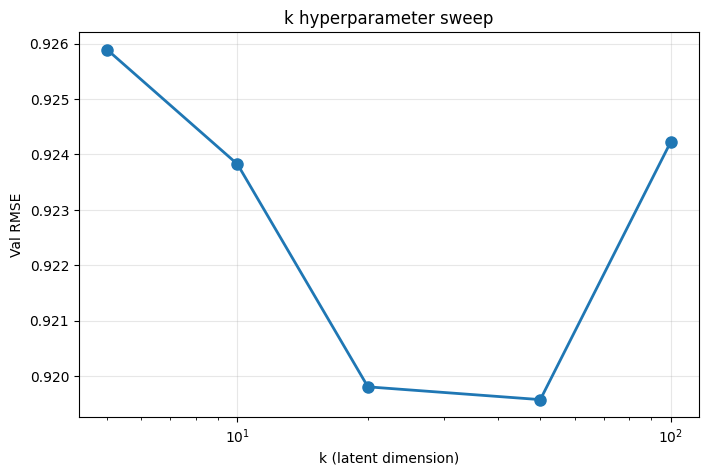

<Figure size 640x480 with 0 Axes>

In [18]:
import time

k_values = [5, 10, 20, 50, 100]
results = []

for k_test in k_values:
    print(f"\n=== k = {k_test} 학습 중 ===")
    start = time.time()
    
    # 초기화
    np.random.seed(42)
    P = np.random.normal(0, 0.1, (n_users, k_test))
    Q = np.random.normal(0, 0.1, (n_items, k_test))
    Y = np.random.normal(0, 0.1, (n_items, k_test))
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)
    
    epochs = 20
    lr = 0.005
    reg = 0.02
    
    for epoch in range(epochs):
        order = np.random.permutation(len(ratings))
        for idx in order:
            u, i, r = users[idx], items[idx], ratings[idx]
            I_u = user_rated_items[u]
            norm = 1.0 / np.sqrt(len(I_u))
            sum_y = Y[I_u].sum(axis=0)
            p_aug = P[u] + norm * sum_y
            
            pred = mu + bu[u] + bi[i] + p_aug @ Q[i]
            err = r - pred
            
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])
            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * p_aug - reg * Q[i])
            Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])
    
    # 검증 RMSE 계산
    P_aug = P.copy()
    for u in range(n_users):
        if u in user_rated_items:
            I_u = user_rated_items[u]
            norm = 1.0 / np.sqrt(len(I_u))
            P_aug[u] += norm * Y[I_u].sum(axis=0)
    
    val_preds = mu + bu[val_users] + bi[val_items] + np.sum(P_aug[val_users] * Q[val_items], axis=1)
    val_rmse = np.sqrt(np.mean((val_preds - val_ratings) ** 2))
    
    elapsed = time.time() - start
    print(f"  val RMSE = {val_rmse:.4f},  학습 시간 = {elapsed:.1f}s")
    results.append({'k': k_test, 'val_rmse': val_rmse, 'time': elapsed})

# 표로 정리
import pandas as pd
df = pd.DataFrame(results)
print("\n=== K sweep 결과 ===")
print(df)

# 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(df['k'], df['val_rmse'], 'o-', linewidth=2, markersize=8)
plt.xlabel('k (latent dimension)')
plt.ylabel('Val RMSE')
plt.title('k hyperparameter sweep')
plt.grid(alpha=0.3)
plt.xscale('log')
plt.show()
plt.savefig('k_sweep.png', dpi=150, bbox_inches='tight')

In [19]:
#최종 모델 학습 (k=20)
np.random.seed(42)
k = 20
P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))
Y = np.random.normal(0, 0.1, (n_items, k))
bu = np.zeros(n_users)
bi = np.zeros(n_items)
mu = train_set['rating'].mean()
lr, epochs, reg = 0.005, 20, 0.02

for epoch in range(epochs):
    order = np.random.permutation(len(ratings))
    for idx in order:
        u, i, r = users[idx], items[idx], ratings[idx]
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        p_aug = P[u] + norm * Y[I_u].sum(axis=0)
        err = r - (mu + bu[u] + bi[i] + p_aug @ Q[i])
        bu[u] += lr * (err - reg * bu[u])
        bi[i] += lr * (err - reg * bi[i])
        P[u] += lr * (err * Q[i] - reg * P[u])
        Q[i] += lr * (err * p_aug - reg * Q[i])
        Y[I_u] += lr * (err * norm * Q[i] - reg * Y[I_u])
print("최종 모델 학습 완료 (k=20)")

최종 모델 학습 완료 (k=20)


In [20]:
#모든 사용자에게 top-k 추천 생성
K = 10  # 추천 개수

# augmented P
P_aug = P.copy()
for u in range(n_users):
    if u in user_rated_items:
        I_u = user_rated_items[u]
        norm = 1.0 / np.sqrt(len(I_u))
        P_aug[u] += norm * Y[I_u].sum(axis=0)

# 학습데이터에서 이미 평가한 아이템 (추천 제외용)
train_items_per_user = {u: set(its) for u, its in user_rated_items.items()}

recommendations = {}
for u in range(n_users):
    scores = mu + bu[u] + bi + P_aug[u] @ Q.T   # 모든 아이템 점수
    for i in train_items_per_user.get(u, set()):
        scores[i] = -np.inf                       # 이미 본 건 제외
    topk = np.argpartition(-scores, K)[:K]
    topk = topk[np.argsort(-scores[topk])]
    recommendations[u] = topk.tolist()

print(f"추천 생성 완료: {len(recommendations)}명 × {K}개")

추천 생성 완료: 943명 × 10개


In [21]:
# 아이템 인기도 (ua.base 평가 횟수)
popularity_counts = np.bincount(items, minlength=n_items)

# 인기 top-K (의외성 baseline = "뻔한 추천")
popular_topk = set(np.argsort(-popularity_counts)[:K].tolist())

In [22]:
# 커버리지: 추천에 등장한 unique 아이템 비율
def coverage(recs, n_items):
    rec_set = set()
    for its in recs.values():
        rec_set.update(its)
    return len(rec_set) / n_items

# 의외성: top-K 중 인기 baseline에 없는 비율 (강의 7.3 정의)
def serendipity(recs, popular_set, K):
    s = [sum(1 for i in its[:K] if i not in popular_set) / K
         for its in recs.values()]
    return np.mean(s)

# 참신성: 추천 아이템의 평균 정보량 -log2(인기도). 높을수록 덜 알려진 아이템
def novelty(recs, pop_counts, n_users, K):
    s = []
    for its in recs.values():
        novs = [-np.log2(max(pop_counts[i] / n_users, 1e-9)) for i in its[:K]]
        s.append(np.mean(novs))
    return np.mean(s)

# 다양성: 추천 리스트 내 아이템 간 평균 비유사도 (Q 벡터 코사인 기반)
def diversity(recs, Q, K):
    s = []
    for its in recs.values():
        topk = its[:K]
        if len(topk) < 2:
            continue
        vecs = Q[topk]
        normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
        sim = normed @ normed.T
        n = len(topk)
        avg_sim = np.sum(np.triu(sim, k=1)) / (n * (n - 1) / 2)
        s.append(1 - avg_sim)   # 다양성 = 1 - 유사도
    return np.mean(s)

# 실행
print(f"=== 정확성 외 메트릭 (Stage 4 MF, K={K}) ===")
print(f"커버리지 (Coverage)    : {coverage(recommendations, n_items):.4f}")
print(f"의외성   (Serendipity) : {serendipity(recommendations, popular_topk, K):.4f}")
print(f"참신성   (Novelty)     : {novelty(recommendations, popularity_counts, n_users, K):.4f}")
print(f"다양성   (Diversity)   : {diversity(recommendations, Q, K):.4f}")

=== 정확성 외 메트릭 (Stage 4 MF, K=10) ===
커버리지 (Coverage)    : 0.0945
의외성   (Serendipity) : 0.9380
참신성   (Novelty)     : 2.7111
다양성   (Diversity)   : 0.6316


np.linalg.norm(..., keepdims=True) 각 벡터의 크기(L2 norm) 계산
normed @ normed.T 정규화된 벡터끼리 내적 = 코사인 유사도 행렬
np.triu(sim, k=1) 대각선 위쪽만 (중복 쌍 제거)
1 - avg_sim 유사도가 낮을수록 다양성이 높음

커버리지: 전체 아이템 중 추천에 한 번이라도 등장한 아이템 비율
의외성: top-K 추천 중 인기 아이템이 아닌 것의 비율 
참신성: -log2(인기도)-> 덜 알려진 아이템일수록 높은 점수

In [23]:
ratings_per_user = train_set.groupby('user').size()
print(f"사용자당 평점 수 — 평균 {ratings_per_user.mean():.0f}, "
      f"중앙값 {ratings_per_user.median():.0f}, "
      f"최소 {ratings_per_user.min()}, 최대 {ratings_per_user.max()}")

사용자당 평점 수 — 평균 82, 중앙값 46, 최소 6, 최대 629


In [24]:
val_relevant = val_set[val_set['rating'] >= 4].groupby('user').size()
print(f"검증셋 사용자당 relevant(평점>=4) — 평균 {val_relevant.mean():.1f}, "
      f"중앙값 {val_relevant.median():.0f}")

검증셋 사용자당 relevant(평점>=4) — 평균 8.7, 중앙값 5


In [25]:
ratings_per_user = train_set.groupby('user').size()

def user_group(u):
    n = ratings_per_user.get(u, 0)
    if n < 30:   return '1_cold (<30)'
    elif n < 80: return '2_medium (30-80)'
    else:        return '3_active (80+)'

vu = val_set['user'].values
vi = val_set['item'].values
vr = val_set['rating'].values
val_pred = mu + bu[vu] + bi[vi] + np.sum(P_aug[vu]*Q[vi], axis=1)

val_g = val_set.copy()
val_g['group'] = val_g['user'].map(user_group)
val_g['sq_err'] = (val_pred - vr) ** 2

print("그룹별 RMSE:")
for g, grp in val_g.groupby('group'):
    rmse = np.sqrt(grp['sq_err'].mean())
    print(f"  {g}: RMSE={rmse:.4f} (평가 {len(grp)}건)")

그룹별 RMSE:
  1_cold (<30): RMSE=1.0266 (평가 976건)
  2_medium (30-80): RMSE=0.9316 (평가 2047건)
  3_active (80+): RMSE=0.9070 (평가 10563건)


In [26]:
#k 정당화-사용자당 평점 수 분석
ratings_per_user = train_set.groupby('user').size()

print("사용자당 평점 수 통계:")
print(f"  평균 {ratings_per_user.mean():.0f}, 중앙값 {ratings_per_user.median():.0f}")
print(f"  최소 {ratings_per_user.min()}, 최대 {ratings_per_user.max()}")
print()
print(f"  k=20  → 평균 사용자가 파라미터 1개당 평점 {ratings_per_user.mean()/20:.1f}개 보유")
print(f"  k=100 → 평균 사용자가 파라미터 1개당 평점 {ratings_per_user.mean()/100:.1f}개 보유")

사용자당 평점 수 통계:
  평균 82, 중앙값 46
  최소 6, 최대 629

  k=20  → 평균 사용자가 파라미터 1개당 평점 4.1개 보유
  k=100 → 평균 사용자가 파라미터 1개당 평점 0.8개 보유


[결과 해석]
k=20 → 파라미터당 평점 4.1개 (넉넉)
k=100 → 파라미터당 평점 0.8개 (1개 미만! 데이터보다 파라미터가 많음)

중앙값이 46(평균 82보다 훨씬 작음) → 분포가 우편향. 즉 전형적인 사용자는 평점이 더 적어서:

중앙값 사용자(46개) 기준 k=100 → 파라미터당 0.46개 → 심각한 과적합 불가피

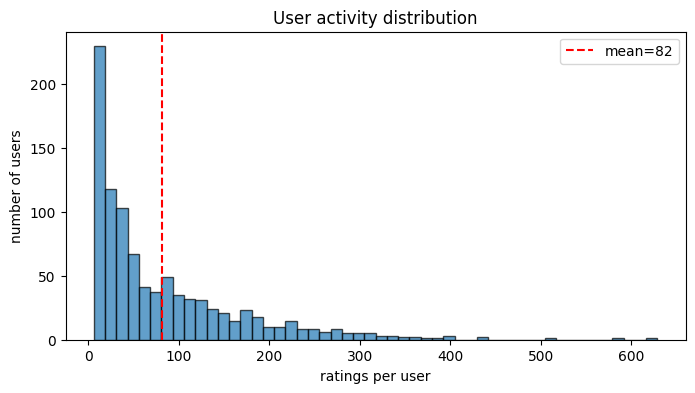

In [27]:
#k 정당화 — 사용자당 평점 수 분석 분포 그래프
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(ratings_per_user.mean(), color='red', linestyle='--', label=f'mean={ratings_per_user.mean():.0f}')
plt.xlabel('ratings per user')
plt.ylabel('number of users')
plt.title('User activity distribution')
plt.legend()
plt.show()

In [28]:
#top-K 정당화 — 검증셋 relevant 분포
val_relevant = val_set[val_set['rating'] >= 4].groupby('user').size()

print("검증셋 사용자당 relevant(평점>=4) 아이템:")
print(f"  평균 {val_relevant.mean():.1f}, 중앙값 {val_relevant.median():.0f}")
print(f"  최소 {val_relevant.min()}, 최대 {val_relevant.max()}")
print(f"  relevant 있는 사용자 수: {len(val_relevant)} / 943")

검증셋 사용자당 relevant(평점>=4) 아이템:
  평균 8.7, 중앙값 5
  최소 1, 최대 72
  relevant 있는 사용자 수: 858 / 943


사용자당 relevant(≥4) 평균 8.7개, 중앙값 5개
top-K=10 ≥ 평균 relevant(8.7) → 선호 아이템을 충분히 담을 크기

In [1]:
#머지 테스트
import pandas as pd

print("=" * 50)
print("split 일치 확인 — 모든 k 값에 대해")
print("=" * 50)

all_aligned = True
for k in [5, 10, 20, 50, 100]:
    mf  = pd.read_csv(f'outputs/valid_mf_k{k}.csv')
    ucf = pd.read_csv(f'outputs/valid_user_cf_k{k}.csv')
    merged = mf.merge(ucf, on=['user_id', 'item_id'], suffixes=('_mf', '_ucf'))
    
    aligned = len(mf) == len(ucf) == len(merged)
    status = "->일치" if aligned else "->불일치"
    print(f"\nk={k}: MF={len(mf)}, UCF={len(ucf)}, Merge={len(merged)}  {status}")
    if not aligned:
        all_aligned = False
        print(f"   불일치 정도: MF에만 {len(mf)-len(merged)}, UCF에만 {len(ucf)-len(merged)}")

print()
print("=" * 50)
if all_aligned:
    print(" 모든 k에서 split 완벽 일치 — 앙상블 진행 가능!")
else:
    print(" 일부 불일치 — 팀원에게 재확인 필요")
print("=" * 50)

split 일치 확인 — 모든 k 값에 대해

k=5: MF=13586, UCF=13586, Merge=13586  ->일치

k=10: MF=13586, UCF=13586, Merge=13586  ->일치

k=20: MF=13586, UCF=13586, Merge=13586  ->일치

k=50: MF=13586, UCF=13586, Merge=13586  ->일치

k=100: MF=13586, UCF=13586, Merge=13586  ->일치

 모든 k에서 split 완벽 일치 — 앙상블 진행 가능!


In [30]:
import numpy as np
import pandas as pd

# 데이터 로드 (split 정보 재현 — 인기도 baseline용)
df = pd.read_csv('ml-100k/ua.base', sep='\t',
                 names=['user', 'item', 'rating', 'timestamp'])
df['user'] -= 1
df['item'] -= 1

np.random.seed(42)
perm = np.random.permutation(len(df))
split = int(len(df) * 0.85)
train_set = df.iloc[perm[:split]].reset_index(drop=True)

# 인기도 계산 (학습셋 기준)
N_USERS, N_ITEMS, TOPK = 943, 1682, 10
popularity_counts = np.bincount(train_set['item'].values, minlength=N_ITEMS)
popular_topk_set = set(np.argsort(-popularity_counts)[:TOPK].tolist())

# UserCF는 item latent vector가 없으니 Diversity 계산을 위해 
# 아이템 표현이 필요. 두 가지 옵션:
#   A) MF의 Q 행렬을 빌려와서 동일 기준으로 비교 (공정한 비교)
#   B) item rating profile (sparse) 사용 (UserCF 자체 표현)
# → A를 추천 (강의 7.3: "잠재요인 모델의 feature도 사용 가능")
# → 비교를 위해선 같은 거리 기준이 좋음

# A 옵션: MF로 학습된 Q 사용. 이미 outputs에 모델 저장 안 했으면 재학습 필요.
# 일단 B 옵션 (rating profile)으로 가자. MF Q를 쓰려면 별도 저장 필요.

# B 옵션: item rating profile로 diversity 계산
from scipy.sparse import csr_matrix
# 각 아이템의 평점 패턴을 벡터로
item_profiles = np.zeros((N_ITEMS, N_USERS))
for u, i, r in zip(train_set['user'].values, train_set['item'].values, train_set['rating'].values):
    item_profiles[i, u] = r

def compute_metrics_from_recs(recs_df, K=10):
    """recs_df: user_id, rank, item_id, pred_rating (1-indexed)"""
    recs_df = recs_df.copy()
    recs_df['user0'] = recs_df['user_id'] - 1
    recs_df['item0'] = recs_df['item_id'] - 1
    
    recommendations = recs_df.groupby('user0')['item0'].apply(list).to_dict()
    
    # Coverage
    rec_set = set()
    for its in recommendations.values():
        rec_set.update(its)
    coverage = len(rec_set) / N_ITEMS
    
    ser, nov, div = [], [], []
    for its in recommendations.values():
        topk = its[:K]
        ser.append(sum(1 for i in topk if i not in popular_topk_set) / K)
        novs = [-np.log2(max(popularity_counts[i] / N_USERS, 1e-9)) for i in topk]
        nov.append(np.mean(novs))
        if len(topk) >= 2:
            vecs = item_profiles[topk]
            normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
            sim = normed @ normed.T
            n = len(topk)
            div.append(1 - np.sum(np.triu(sim, k=1)) / (n*(n-1)/2))
    return coverage, np.mean(ser), np.mean(nov), np.mean(div)


# 5개 k에 대해 계산
print("UserCF beyond-accuracy 메트릭 (top-K=10):")
print(f"{'k':>5} {'Coverage':>10} {'Serendipity':>12} {'Novelty':>10} {'Diversity':>10}")
print("-" * 50)
for k in [5, 10, 20, 50, 100]:
    recs = pd.read_csv(f'outputs/valid_user_cf_recs_k{k}.csv')
    cov, ser, nov, div = compute_metrics_from_recs(recs, K=10)
    print(f"{k:>5} {cov:>10.4f} {ser:>12.4f} {nov:>10.4f} {div:>10.4f}")

UserCF beyond-accuracy 메트릭 (top-K=10):
    k   Coverage  Serendipity    Novelty  Diversity
--------------------------------------------------
    5     0.5256       0.6452     3.0283     0.7409
   10     0.5054       0.6458     2.9955     0.7330
   20     0.4899       0.6442     2.9627     0.7265
   50     0.4810       0.6410     2.9203     0.7216
  100     0.4845       0.6388     2.9204     0.7225


In [31]:
import numpy as np
import pandas as pd

# 데이터 + 인기도 (변수 메모리에 있으면 스킵)
N_USERS, N_ITEMS = 943, 1682

df = pd.read_csv('ml-100k/ua.base', sep='\t',
                 names=['user', 'item', 'rating', 'timestamp'])
df['user'] -= 1
df['item'] -= 1

np.random.seed(42)
perm = np.random.permutation(len(df))
split = int(len(df) * 0.85)
train_set = df.iloc[perm[:split]].reset_index(drop=True)

# 표현 1: MF의 Q 행렬 — 너가 이미 학습해뒀으면 그 변수 그대로 사용
# (없으면 mf_generate_outputs.py를 k=20에서만 다시 돌리고 Q 저장)
# Q 변수가 메모리에 있다고 가정. 없으면 아래 주석 해제:
# from your_mf_training_code import P, Q, Y, bu, bi, mu

# 표현 2: item rating profile (UserCF에서 썼던 것)
item_profiles = np.zeros((N_ITEMS, N_USERS))
for u, i, r in zip(train_set['user'].values, train_set['item'].values,
                    train_set['rating'].values):
    item_profiles[i, u] = r

def diversity(recs_df, item_vectors, K=10):
    """주어진 item_vectors 기준으로 추천 리스트의 평균 비유사도"""
    recs_df = recs_df.copy()
    recs_df['item0'] = recs_df['item_id'] - 1
    recs_df['user0'] = recs_df['user_id'] - 1
    
    div_scores = []
    for u, group in recs_df.groupby('user0'):
        topk = group.sort_values('rank')['item0'].tolist()[:K]
        if len(topk) < 2:
            continue
        vecs = item_vectors[topk]
        normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
        sim = normed @ normed.T
        n = len(topk)
        div_scores.append(1 - np.sum(np.triu(sim, k=1)) / (n*(n-1)/2))
    return np.mean(div_scores)

# 두 모델 × 두 표현 = 2x2 표
mf_recs_k20  = pd.read_csv('outputs/valid_mf_recs_k20.csv')
ucf_recs_k50 = pd.read_csv('outputs/valid_user_cf_recs_k50.csv')

print("Diversity 비교 — 두 측정 방식")
print("=" * 55)
print(f"{'':25s}{'MF Q 기준':>14s}{'rating profile':>16s}")
print("-" * 55)
print(f"{'MF (k=20) 추천':25s}{diversity(mf_recs_k20, Q):>14.4f}{diversity(mf_recs_k20, item_profiles):>16.4f}")
print(f"{'UserCF (k=50) 추천':25s}{diversity(ucf_recs_k50, Q):>14.4f}{diversity(ucf_recs_k50, item_profiles):>16.4f}")

Diversity 비교 — 두 측정 방식
                                MF Q 기준  rating profile
-------------------------------------------------------
MF (k=20) 추천                     0.6316          0.6836
UserCF (k=50) 추천                 0.8778          0.7216


In [32]:
import numpy as np
import pandas as pd

def diversity(recs_df, item_vectors, K=10):
    """주어진 임베딩 공간에서 추천 리스트의 평균 비유사도"""
    recs_df = recs_df.copy()
    recs_df['item0'] = recs_df['item_id'] - 1
    recs_df['user0'] = recs_df['user_id'] - 1
    
    div_scores = []
    for u, group in recs_df.groupby('user0'):
        topk = group.sort_values('rank')['item0'].tolist()[:K]
        if len(topk) < 2:
            continue
        vecs = item_vectors[topk]
        normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
        sim = normed @ normed.T
        n = len(topk)
        div_scores.append(1 - np.sum(np.triu(sim, k=1)) / (n*(n-1)/2))
    return np.mean(div_scores)

print("=" * 65)
print("Diversity 전체 측정 (참조 공간: MF k=20의 Q + rating profile)")
print("=" * 65)
print(f"{'모델':>10} {'k':>5} {'MF Q 기준':>14} {'profile 기준':>16}")
print("-" * 65)

# MF 추천을 모든 k에서 측정
for k in [5, 10, 20, 50, 100]:
    mf_recs = pd.read_csv(f'outputs/valid_mf_recs_k{k}.csv')
    d_q = diversity(mf_recs, Q)
    d_p = diversity(mf_recs, item_profiles)
    print(f"{'MF':>10} {k:>5} {d_q:>14.4f} {d_p:>16.4f}")

print()  # 구분선

# UserCF 추천을 모든 k에서 측정
for k in [5, 10, 20, 50, 100]:
    ucf_recs = pd.read_csv(f'outputs/valid_user_cf_recs_k{k}.csv')
    d_q = diversity(ucf_recs, Q)
    d_p = diversity(ucf_recs, item_profiles)
    print(f"{'UserCF':>10} {k:>5} {d_q:>14.4f} {d_p:>16.4f}")

Diversity 전체 측정 (참조 공간: MF k=20의 Q + rating profile)
        모델     k        MF Q 기준       profile 기준
-----------------------------------------------------------------
        MF     5         0.6371           0.6761
        MF    10         0.6305           0.6897
        MF    20         0.6316           0.6836
        MF    50         0.6558           0.6909
        MF   100         0.6833           0.6972

    UserCF     5         0.9051           0.7409
    UserCF    10         0.8908           0.7330
    UserCF    20         0.8830           0.7265
    UserCF    50         0.8778           0.7216
    UserCF   100         0.8777           0.7225


In [34]:
import numpy as np
import pandas as pd

N_USERS, N_ITEMS, TOPK = 943, 1682, 10

# === 통일된 top-K 생성 함수 (validation 후보 방식) ===
def make_recs_from_predictions(pred_df, K=10):
    """prediction CSV에서 사용자별 pred_rating top-K를 recs DataFrame으로"""
    df = pred_df.copy()
    df = df.sort_values(['user_id', 'pred_rating'], ascending=[True, False])
    df['rank'] = df.groupby('user_id').cumcount() + 1
    return df[df['rank'] <= K][['user_id', 'rank', 'item_id', 'pred_rating']]

# === 통일된 메트릭 함수 (이전 코드 그대로) ===
popular_topk_set = set(np.argsort(-popularity_counts)[:TOPK].tolist())

def compute_metrics(recs_df, item_vectors_for_diversity, K=10):
    recs_df = recs_df.copy()
    recs_df['item0'] = recs_df['item_id'] - 1
    recs_df['user0'] = recs_df['user_id'] - 1
    recommendations = recs_df.groupby('user0')['item0'].apply(list).to_dict()
    
    rec_set = set()
    for its in recommendations.values():
        rec_set.update(its)
    coverage = len(rec_set) / N_ITEMS
    
    ser, nov, div = [], [], []
    for its in recommendations.values():
        topk = its[:K]
        ser.append(sum(1 for i in topk if i not in popular_topk_set) / K)
        novs = [-np.log2(max(popularity_counts[i] / N_USERS, 1e-9)) for i in topk]
        nov.append(np.mean(novs))
        if len(topk) >= 2:
            vecs = item_vectors_for_diversity[topk]
            normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
            sim = normed @ normed.T
            n = len(topk)
            div.append(1 - np.sum(np.triu(sim, k=1)) / (n*(n-1)/2))
    return coverage, np.mean(ser), np.mean(nov), np.mean(div)


# === 셋 다 계산 ===
print(f"{'모델':>25} {'RMSE':>8} {'Cov':>8} {'Ser':>8} {'Nov':>8} {'Div':>8}")
print("-" * 70)

models = [
    ('MF k=20',         'outputs/valid_mf_k20.csv',          Q),
    ('MF k=50',         'outputs/valid_mf_k50.csv',          Q),
    ('UserCF k=50',     'outputs/valid_user_cf_k50.csv',     item_profiles),
    # 앙상블 prediction csv 받으면 아래 추가:
    # ('Weighted Ens k=50','outputs/ensemble_prediction.csv',  Q),  # diversity는 Q로
    # ('True Bagging UCF', 'outputs/bagging_prediction.csv',   item_profiles),
    # ('Boosting UCF',     'outputs/boosting_prediction.csv',  item_profiles),
]

for name, path, vecs in models:
    try:
        pred = pd.read_csv(path)
        recs = make_recs_from_predictions(pred, K=TOPK)
        rmse = np.sqrt(np.mean((pred['pred_rating'] - pred['true_rating'])**2))
        cov, ser, nov, div = compute_metrics(recs, vecs, K=TOPK)
        print(f"{name:>25} {rmse:>8.4f} {cov:>8.4f} {ser:>8.4f} {nov:>8.4f} {div:>8.4f}")
    except FileNotFoundError:
        print(f"{name:>25}  파일 없음 (스킵)")

                       모델     RMSE      Cov      Ser      Nov      Div
----------------------------------------------------------------------
                  MF k=20   0.9196   0.4958   0.6409   2.9659   0.8713
                  MF k=50   0.9192   0.5059   0.6430   2.9675   0.8750
              UserCF k=50   1.0156   0.4810   0.6410   2.9203   0.7216


In [ ]:
import numpy as np
import pandas as pd

# ============================================
# 1. 데이터 로드 & 학습/검증 분리 
# ============================================
N_USERS, N_ITEMS, TOPK = 943, 1682, 10

df = pd.read_csv('ml-100k/ua.base', sep='\t',
                 names=['user', 'item', 'rating', 'timestamp'])
df['user'] -= 1
df['item'] -= 1

np.random.seed(42)
perm = np.random.permutation(len(df))
split_idx = int(len(df) * 0.85)
train_set = df.iloc[perm[:split_idx]].reset_index(drop=True)

# 인기도 계산 (학습 기준)
popularity_counts = np.bincount(train_set['item'].values, minlength=N_ITEMS)
popular_topk_set = set(np.argsort(-popularity_counts)[:TOPK].tolist())

# 아이템 rating profile (diversity용 — 모든 모델 공통)
item_profiles = np.zeros((N_ITEMS, N_USERS))
for u, i, r in zip(train_set['user'].values, train_set['item'].values,
                    train_set['rating'].values):
    item_profiles[i, u] = r

# ============================================
# 2. 핵심 변경: validation 후보 기반 top-K 생성
# ============================================
def make_recs_from_predictions(pred_df, K=10):
    """
    [기존] valid_mf_recs_k20.csv (전체 카탈로그에서 생성된 recs)를 사용
    [변경] valid_mf_k20.csv (prediction CSV)에서 사용자별 pred_rating 상위 K개 추출
    """
    df = pred_df.copy()
    df = df.sort_values(['user_id', 'pred_rating'], ascending=[True, False])
    df['rank'] = df.groupby('user_id').cumcount() + 1
    return df[df['rank'] <= K][['user_id', 'rank', 'item_id', 'pred_rating']]

# ============================================
# 3. 메트릭 함수 (이전과 동일)
# ============================================
def compute_unified_metrics(recs_df, K=10):
    recs_df = recs_df.copy()
    recs_df['item0'] = recs_df['item_id'] - 1
    recs_df['user0'] = recs_df['user_id'] - 1
    recommendations = recs_df.groupby('user0')['item0'].apply(list).to_dict()
    
    # Coverage
    rec_set = set()
    for its in recommendations.values():
        rec_set.update(its)
    coverage = len(rec_set) / N_ITEMS
    
    ser, nov, div = [], [], []
    for its in recommendations.values():
        topk = its[:K]
        # Serendipity
        ser.append(sum(1 for i in topk if i not in popular_topk_set) / K)
        # Novelty
        novs = [-np.log2(max(popularity_counts[i] / N_USERS, 1e-9)) for i in topk]
        nov.append(np.mean(novs))
        # Diversity (rating profile 기준 — 모든 모델 공통)
        if len(topk) >= 2:
            vecs = item_profiles[topk]
            normed = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
            sim = normed @ normed.T
            n = len(topk)
            div.append(1 - np.sum(np.triu(sim, k=1)) / (n*(n-1)/2))
    return coverage, np.mean(ser), np.mean(nov), np.mean(div)

# ============================================
# 4. 모든 모델 한 번에 계산
# ============================================
print("=" * 75)
print("통일 메트릭 (validation 후보 기반 top-10)")
print("=" * 75)
print(f"{'모델':>35} {'RMSE':>8} {'Cov':>8} {'Ser':>8} {'Nov':>8} {'Div':>8}")
print("-" * 75)

# --- MF ---
for k in [5, 10, 20, 50, 100]:
    pred = pd.read_csv(f'outputs/valid_mf_k{k}.csv')
    recs = make_recs_from_predictions(pred)
    rmse = np.sqrt(np.mean((pred['pred_rating'] - pred['true_rating'])**2))
    cov, ser, nov, div = compute_unified_metrics(recs)
    print(f"{'MF k=' + str(k):>35} {rmse:>8.4f} {cov:>8.4f} {ser:>8.4f} {nov:>8.4f} {div:>8.4f}")

print()
# --- UserCF ---
for k in [5, 10, 20, 50, 100]:
    pred = pd.read_csv(f'outputs/valid_user_cf_k{k}.csv')
    recs = make_recs_from_predictions(pred)
    rmse = np.sqrt(np.mean((pred['pred_rating'] - pred['true_rating'])**2))
    cov, ser, nov, div = compute_unified_metrics(recs)
    print(f"{'UserCF k=' + str(k):>35} {rmse:>8.4f} {cov:>8.4f} {ser:>8.4f} {nov:>8.4f} {div:>8.4f}")

print()
# --- 앙상블 모델들 ---
ensemble_files = [
    ('W.Ens same-k (k=50)',       'ensemble_outputs/valid_stage3_weighted_ensemble_best.csv'),
    ('W.Ens all-pair (best)',     'ensemble_outputs/valid_stage6_all_pair_weighted_best.csv'),
    ('Boosting UCF (k=50)',       'ensemble_outputs/valid_stage4_boosting_usercf.csv'),
    ('True Bagging UCF (k=20)',   'ensemble_outputs/valid_true_bagging_usercf_k20.csv'),
]

for name, path in ensemble_files:
    try:
        pred = pd.read_csv(path)
        recs = make_recs_from_predictions(pred)
        rmse = np.sqrt(np.mean((pred['pred_rating'] - pred['true_rating'])**2))
        cov, ser, nov, div = compute_unified_metrics(recs)
        print(f"{name:>35} {rmse:>8.4f} {cov:>8.4f} {ser:>8.4f} {nov:>8.4f} {div:>8.4f}")
    except FileNotFoundError:
        print(f"{name:>35}  파일 없음 (스킵)")

통일 메트릭 (validation 후보 기반 top-10)
                                 모델     RMSE      Cov      Ser      Nov      Div
---------------------------------------------------------------------------
                             MF k=5   0.9257   0.4952   0.6399   2.9598   0.7258
                            MF k=10   0.9236   0.4964   0.6405   2.9633   0.7276
                            MF k=20   0.9196   0.4958   0.6409   2.9659   0.7283
                            MF k=50   0.9192   0.5059   0.6430   2.9675   0.7291
                           MF k=100   0.9239   0.5089   0.6416   2.9746   0.7307

                         UserCF k=5   1.0870   0.5244   0.6450   3.0270   0.7407
                        UserCF k=10   1.0450   0.5054   0.6457   2.9950   0.7330
                        UserCF k=20   1.0244   0.4899   0.6442   2.9627   0.7265
                        UserCF k=50   1.0156   0.4810   0.6410   2.9203   0.7216
                       UserCF k=100   1.0177   0.4845   0.6388   2.9204   0.7225

In [ ]:
import numpy as np
import pandas as pd

# ============================================
# 1. 데이터 로드 (팀원 stage5와 동일한 방식)
# ============================================
N_ITEMS = 1682
TOP_K = 10

# 변경 1: 인기도를 전체 ua.base에서 계산 (팀원 방식)
ua_base = pd.read_csv('ml-100k/ua.base', sep='\t',
                       names=['user_id', 'item_id', 'rating', 'timestamp'])

popularity_counts = ua_base.groupby('item_id').size().to_dict()
n_users = ua_base['user_id'].nunique()

popular_set = set(
    ua_base.groupby('item_id').size()
    .sort_values(ascending=False)
    .head(TOP_K).index.astype(int).tolist()
)

# 변경 2: 장르 벡터 로드 (팀원 방식)
item_df = pd.read_csv('ml-100k/u.item', sep='|', header=None, encoding='latin-1')
genre_cols = list(range(5, item_df.shape[1]))
genre_dict = {}
for _, row in item_df.iterrows():
    item_id = int(row[0])
    genre_dict[item_id] = row[genre_cols].to_numpy(dtype=float)

# ============================================
# 2. 변경 3: prediction CSV에서 top-K 추출 (팀원 방식)
# ============================================
def make_recommendations(df, top_k=10):
    """기존: valid_mf_recs_k20.csv 사용
       변경: valid_mf_k20.csv에서 사용자별 pred_rating 상위 K개"""
    rec_df = (
        df.sort_values(['user_id', 'pred_rating'], ascending=[True, False])
        .groupby('user_id').head(top_k)
    )
    return (
        rec_df.groupby('user_id')['item_id']
        .apply(lambda x: list(x.astype(int)))
        .to_dict()
    )

# ============================================
# 3. 메트릭 함수 (팀원 stage5와 완전 동일)
# ============================================
def calc_coverage(recs):
    rec_set = set()
    for items in recs.values():
        rec_set.update(items)
    return len(rec_set) / N_ITEMS

def calc_novelty(recs):
    scores = []
    for items in recs.values():
        item_scores = []
        for iid in items[:TOP_K]:
            pop = popularity_counts.get(iid, 0)
            prob = max(pop / n_users, 1e-9)
            item_scores.append(-np.log2(prob))
        if item_scores:
            scores.append(np.mean(item_scores))
    return np.mean(scores)

def calc_serendipity(recs):
    scores = []
    for items in recs.values():
        top_items = items[:TOP_K]
        if not top_items:
            continue
        scores.append(sum(1 for i in top_items if i not in popular_set) / len(top_items))
    return np.mean(scores)

def calc_diversity(recs):
    scores = []
    for items in recs.values():
        vecs = [genre_dict[i] for i in items[:TOP_K] if i in genre_dict]
        if len(vecs) < 2:
            continue
        vecs = np.array(vecs, dtype=float)
        norms = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9
        normed = vecs / norms
        sim = normed @ normed.T
        n = len(vecs)
        pair_count = n * (n - 1) / 2
        if pair_count == 0:
            continue
        scores.append(1 - np.sum(np.triu(sim, k=1)) / pair_count)
    return np.mean(scores) if scores else 0.0

# ============================================
# 4. 전체 모델 계산
# ============================================
def evaluate_model(name, path):
    df = pd.read_csv(path)
    # pred_rating 컬럼 확인 (앙상블 파일은 usercf_pred, mf_pred도 있음)
    if 'pred_rating' not in df.columns:
        print(f"   {name}: pred_rating 컬럼 없음, 스킵")
        return None
    
    rmse = np.sqrt(np.mean((df['pred_rating'] - df['true_rating'])**2))
    mae = np.mean(np.abs(df['pred_rating'] - df['true_rating']))
    recs = make_recommendations(df, TOP_K)
    
    return {
        'model': name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'Coverage': round(calc_coverage(recs), 4),
        'Serendipity': round(calc_serendipity(recs), 4),
        'Novelty': round(calc_novelty(recs), 4),
        'Diversity': round(calc_diversity(recs), 4),
    }

# === 모델 파일 목록 ===
models = [
    # MF
    ('MF k=5',              'outputs/valid_mf_k5.csv'),
    ('MF k=10',             'outputs/valid_mf_k10.csv'),
    ('MF k=20',             'outputs/valid_mf_k20.csv'),
    ('MF k=50',             'outputs/valid_mf_k50.csv'),
    ('MF k=100',            'outputs/valid_mf_k100.csv'),
    # UserCF
    ('UserCF k=5',          'outputs/valid_user_cf_k5.csv'),
    ('UserCF k=10',         'outputs/valid_user_cf_k10.csv'),
    ('UserCF k=20',         'outputs/valid_user_cf_k20.csv'),
    ('UserCF k=50',         'outputs/valid_user_cf_k50.csv'),
    ('UserCF k=100',        'outputs/valid_user_cf_k100.csv'),
    # 앙상블 (ensemble_outputs/ 경로)
    ('W.Ens same-k',        'ensemble_outputs/valid_stage3_weighted_ensemble_best.csv'),
    ('W.Ens all-pair',      'ensemble_outputs/valid_stage6_all_pair_weighted_best.csv'),
    ('Boosting UCF',        'ensemble_outputs/valid_stage4_boosting_usercf.csv'),
    ('Bagging UCF k=50',    'ensemble_outputs/valid_true_bagging_usercf_k50.csv'),
]

print("=" * 80)
print("통일 메트릭 (팀원 stage5 방식: validation top-K + 장르 diversity + ua.base 인기도)")
print("=" * 80)
print(f"{'모델':>20} {'RMSE':>8} {'MAE':>8} {'Cov':>8} {'Ser':>8} {'Nov':>8} {'Div':>8}")
print("-" * 80)

results = []
for name, path in models:
    try:
        r = evaluate_model(name, path)
        if r:
            results.append(r)
            print(f"{r['model']:>20} {r['RMSE']:>8.4f} {r['MAE']:>8.4f} "
                  f"{r['Coverage']:>8.4f} {r['Serendipity']:>8.4f} "
                  f"{r['Novelty']:>8.4f} {r['Diversity']:>8.4f}")
    except FileNotFoundError:
        print(f"{name:>20}  파일 없음 (스킵)")

# 결과 저장
results_df = pd.DataFrame(results)
results_df.to_csv('outputs/unified_metrics_all_models.csv', index=False)
print(f"\n저장: outputs/unified_metrics_all_models.csv")

통일 메트릭 (팀원 stage5 방식: validation top-K + 장르 diversity + ua.base 인기도)
                  모델     RMSE      MAE      Cov      Ser      Nov      Div
--------------------------------------------------------------------------------
              MF k=5   0.9257   0.7293   0.4952   0.9111   2.6915   0.7247
             MF k=10   0.9236   0.7274   0.4964   0.9118   2.6972   0.7238
             MF k=20   0.9196   0.7239   0.4958   0.9121   2.6973   0.7235
             MF k=50   0.9192   0.7232   0.5059   0.9142   2.7070   0.7252
            MF k=100   0.9239   0.7289   0.5089   0.9129   2.7102   0.7228
          UserCF k=5   1.0870   0.8571   0.5244   0.9163   2.7638   0.7237
         UserCF k=10   1.0450   0.8263   0.5054   0.9169   2.7324   0.7225
         UserCF k=20   1.0244   0.8111   0.4899   0.9154   2.6965   0.7228
         UserCF k=50   1.0156   0.8053   0.4810   0.9122   2.6571   0.7255
        UserCF k=100   1.0177   0.8091   0.4845   0.9100   2.6568   0.7269
        W.Ens same-k   0.